In [ ]:
#  多元Logistic回归算法
#1  载入分析所需要的库和模块
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import cohen_kappa_score

Matplotlib is building the font cache; this may take a moment.


In [12]:
#2  数据读取及观察
data=pd.read_csv('数据6.1.csv')
data.info()
len(data.columns) 
data.columns 
data.shape
data.dtypes
data.isnull().values.any() 
data.isnull().sum() 
data.head()
data.V5.value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1034 entries, 0 to 1033
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      1034 non-null   int64  
 1   V2      1034 non-null   int64  
 2   V3      1034 non-null   float64
 3   V4      1034 non-null   float64
 4   V5      1034 non-null   int64  
dtypes: float64(2), int64(3)
memory usage: 40.5 KB


V5
1    478
2    432
3    124
Name: count, dtype: int64

In [ ]:
#3  描述性分析及图形绘制
#3.1  针对连续变量，计算平均值、标准差、最大值、最小值、四分位数等统计指标
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
data.describe()

,V1,V2,V3,V4,V5
count,1034.000000,1034.000000,1034.000000,1034.000000,1034.000000
mean,2.190522,15.105416,161.608027,135.069632,1.657640
std,0.748970,8.635544,55.616922,45.025553,0.682235
min,1.000000,1.000000,24.600000,24.500000,1.000000
25%,2.000000,7.000000,115.425000,99.400000,1.000000
50%,2.000000,15.000000,158.550000,129.750000,2.000000
75%,3.000000,23.000000,206.275000,170.100000,2.000000
max,3.000000,30.000000,298.500000,249.800000,3.000000


Text(0.5, 1.0, '职称情况条形图')

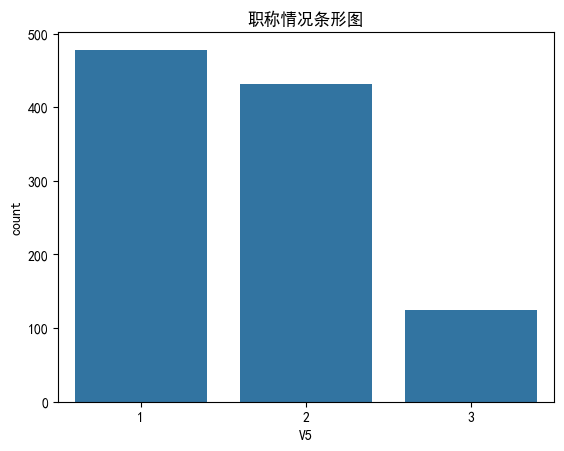

In [4]:
#3.2  绘制职称情况（V5）变量的条形图
sns.countplot(x=data['V5'])#绘制职称情况（V5）的计数条线图
plt.rcParams['font.sans-serif'] = ['SimHei']#解决图表中中文显示问题。
plt.title("职称情况条形图")

/var/folders/6c/31ch_nt53zz9d830gvjhhldm0000gn/T/ipykernel_4471/2113963051.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='V5', y='V2', data=data, palette="Blues")#职称情况（V5）与工作年限（V2）


<Axes: xlabel='V5', ylabel='V2'>

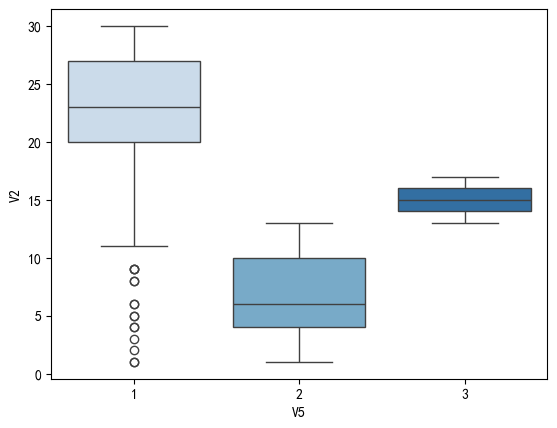

In [6]:
#3.3  绘制箱线图
sns.boxplot(x='V5', y='V2', data=data, palette="Blues")#职称情况（V5）与工作年限（V2）


/var/folders/6c/31ch_nt53zz9d830gvjhhldm0000gn/T/ipykernel_4471/3419466508.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='V5', y='V3', data=data, palette="Reds")#绩效考核得分（V3）和违规操作积分（V4）


<Axes: xlabel='V5', ylabel='V3'>

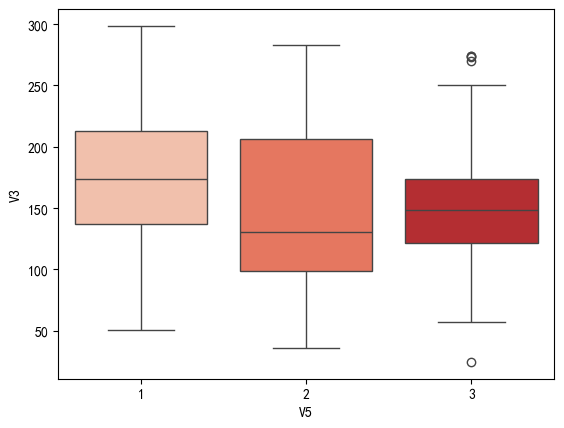

In [ ]:
sns.boxplot(x='V5', y='V3', data=data, palette="Reds")#职称情况（V5）与绩效考核得分（V3）

/var/folders/6c/31ch_nt53zz9d830gvjhhldm0000gn/T/ipykernel_4471/3051024511.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='V5', y='V4', data=data, palette="Greens")


<Axes: xlabel='V5', ylabel='V4'>

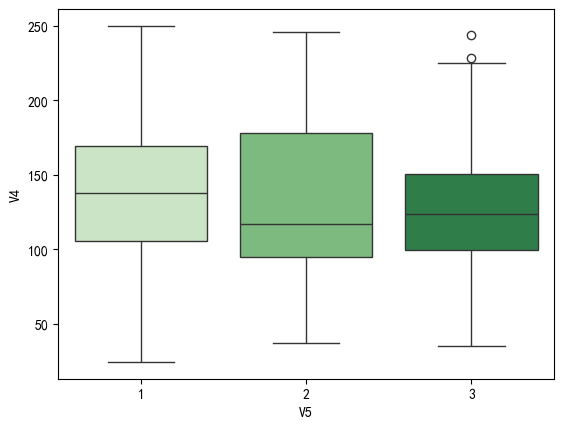

In [11]:
#职称情况（V5）与违规操作积分（V4）
sns.boxplot(x='V5', y='V4', data=data, palette="Greens")

In [21]:
#4数据处理
# 4.1  区分分类特征和连续特征并进行处理，对分类特征设置虚拟变量，对连续特征进行标准化处理；
def data_encoding(data):
    data = data[['V2',"V3","V4","V5"]]
    Discretefeature=[]
    Continuousfeature=['V2',"V3","V4"]
    df = pd.get_dummies(data,columns=Discretefeature)
    df[Continuousfeature]=(df[Continuousfeature]-df[Continuousfeature].mean())/(df[Continuousfeature].std())
    df["V5"]=data[["V5"]]
    return df
data=data_encoding(data)
data.describe()

,V2,V3,V4,V5
count,1034.000000,1034.000000,1.034000e+03,1034.000000
mean,0.000000,0.000000,2.061536e-17,1.657640
std,1.000000,1.000000,1.000000e+00,0.682235
min,-1.633414,-2.463423,-2.455708e+00,1.000000
25%,-0.938611,-0.830377,-7.922086e-01,1.000000
50%,-0.012207,-0.054984,-1.181470e-01,2.000000
75%,0.914197,0.803118,7.780108e-01,2.000000
max,1.724800,2.461337,2.548117e+00,3.000000


In [18]:
#4.2  将样本示例全集分割为训练样本和测试样本，测试样本占比为30%，设定随机数种子为123，以保证随机抽样的结果可重复。
X = data.drop(['V5'],axis=1)#设置特征变量，即除V5之外的全部变量
y = data['V5']#设置响应变量，即V5
X_train, X_test, y_train, y_test =  train_test_split(X,y,test_size=0.3, stratify=y, random_state=123)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((723, 3), (311, 3), (723,), (311,))

In [26]:
#5  建立多元Logistic回归算法模型
#5.1  开展模型估计
model=LogisticRegression(multi_class='multinomial',solver = 'newton-cg', C=1e10, max_iter=int(1e3))
model.fit(X_train, y_train)

model.n_iter_, model.intercept_, model.coef_
#显示模型的迭代次数, 模型的截距项, 模型的回归系数

/Users/longmozhou/Documents/文稿 - LongMacBook Pro/深度学习/cs336/assignment1-basics/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


(array([6], dtype=int32),
 array([ 0.43777712, -0.75540724,  0.31763012]),
 array([[ 3.84713197,  0.4064822 , -0.18582939],
        [-4.40830107, -0.09652221, -0.01704724],
        [ 0.5611691 , -0.30995999,  0.20287662]]))

              precision    recall  f1-score   support

           1       0.86      0.97      0.92       144
           2       0.93      0.98      0.96       130
           3       0.83      0.27      0.41        37

    accuracy                           0.89       311
   macro avg       0.88      0.74      0.76       311
weighted avg       0.89      0.89      0.87       311



0.8138704002611582

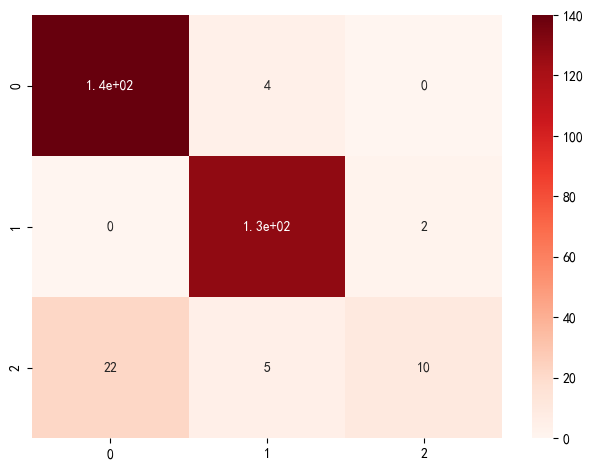

In [27]:
#5.2  模型性能分析
model.score(X_test, y_test)#计算模型预测的准确率
prob = model.predict_proba(X_test)#计算响应变量预测分类概率
prob[:5]#显示前5个样本示例的响应变量预测分类概率。

np.set_printoptions(suppress=True)
prob = model.predict_proba(X_test)#计算响应变量预测分类概率
prob[:5]#显示前5个样本示例的响应变量预测分类概率

pred = model.predict(X_test)#计算响应变量预测分类类型
pred[:5]#显示前5个样本示例的响应变量预测分类类型

table = confusion_matrix(y_test, pred)#基于测试样本输出混淆矩阵
table#显示混淆矩阵

sns.heatmap(table,cmap='Reds', annot=True)
plt.tight_layout()#输出混淆矩阵热图,cmap='r'表示使用红色系， annot=True表示在格子上显示数字

print(classification_report(y_test, pred))#输出详细的预测效果指标

cohen_kappa_score(y_test, pred)#计算kappa得分
